# DSML 4220 - Lab 6: Airline Tweets with (and without) Embeddings

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sgeinitz/DSML4220/blob/main/lab6_airline_tweets_w_embeddings.ipynb)

[![Kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://kaggle.com/kernels/welcome?src=https://github.com/sgeinitz/DSML4220/blob/main/lab6_airline_tweets_w_embeddings.ipynb)

In this notebook we'll revisit the Airline Tweets dataset (from [Lab 1](https://github.com/sgeinitz/DSML4220/blob/main/lab1_text_data.ipynb)) and compare using an MLP with one-hot encodings as the input vs using word embeddings as the input.

In this lab there are three (3) questions/tasks. These questions are listed here but are also inline below.

1. Q1: Choose two words to compare (different from "_wonderful_" vs "_incredible_"). Re-run the parts of the notebook that plot the histogram of the differences between learned weight parameter values for each of your chosen words across the 128 hidden units in the first layer.
2. Q2: Add your two words the list of words whose embeddings are displayed and compared. Do your two chosen words have similar embeddings? In other words, is the distance between your embeddings very small?
3. Q3: Compare the size of the two models used in this notebook, one of which uses one-hot encoded inputs and the other which uses GloVe embeddings.

In [1]:
!pip install torchmetrics
!pip install torchinfo
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 59.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 71.5 MB/s eta 0:00:00


In [2]:
import torch
import random
import tqdm
import notebook
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import torchinfo
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchmetrics.functional import pairwise_cosine_similarity

In [3]:
data_URL = 'https://raw.githubusercontent.com/sgeinitz/DSML4220/main/data/airlinetweets.csv'
df = pd.read_csv(data_URL)
print(f"df.shape: {df.shape}")
pd.set_option("display.max_colwidth", 240)
df.head(10)

df.shape: (10000, 2)


,sentiment,text
0,positive,@JetBlue @JayVig I like the inflight snacks! I'm flying with you guys on 2/28! #JVMChat
1,positive,@VirginAmerica thanks guys! Sweet route over the Rockies #airplanemodewason
2,negative,@USAirways Your exchange/credit policies are worthless and shadier than the White House. Dissatisfied to the nines right now.
3,negative,@USAirways but in the meantime I'll be sleeping on a park bench on dadeland st. Thanks guys!
4,negative,@VirginAmerica hold times at call center are a bit much
5,negative,@USAirways not moving we are in the tarmac delayed for some unknown reason. I'll keep you posted
6,neutral,"@JetBlue What about if I booked it through Orbitz? My email is correct, but there's a middle party."
7,negative,@united 2nd flight also delayed no pilots! But they boarded is so we can just sit here! #scheduling
8,negative,".@AmericanAir after 50 minutes on hold, and another 30 minutes on the call yes. Going to be pushing it to get to the airport on time now"
9,positive,@JetBlue flight 117. proud to fly Jet Blue!


In [4]:
random.seed(2)
indices = list(range(len(df)))
random.shuffle(indices)

df_test = df.iloc[indices[9000:],]
df = df.iloc[indices[:9000],]

In [5]:
df_test.shape
df.shape

(9000, 2)

Recall that about 2/3 of the data have negative labels, and that the remaining labels are roughly split between positive and neutral (slightly more neutral than positive).

In [6]:
df.sentiment.value_counts(normalize=True)

,proportion
sentiment,
negative,0.653556
neutral,0.191111
positive,0.155333


Let's start with the nltk TweetTokenizer, which will split the text into separate words and characters based on common Twitter conventions.

In [7]:
from nltk.tokenize import TweetTokenizer
tk = TweetTokenizer()
df['tokens_raw'] = df['text'].apply(lambda x: tk.tokenize(x.lower()))
df.head()

,sentiment,text,tokens_raw
7010,positive,@AmericanAir I ended up on a flight to LA my fourth time on standby. Thanks! http://t.co/NA5G5EAKPA,"[@americanair, i, ended, up, on, a, flight, to, la, my, fourth, time, on, standby, ., thanks, !, http://t.co/na5g5eakpa]"
9477,neutral,@JetBlue thanks! I only loose 'em at airports...1st time we found it. I think @fitbit needs to make flexes that stay on when carrying bags!,"[@jetblue, thanks, !, i, only, loose, ', em, at, airports, ..., 1st, time, we, found, it, ., i, think, @fitbit, needs, to, make, flexes, that, stay, on, when, carrying, bags, !]"
4584,neutral,@SouthwestAir can take u to Midway-Chicago March 8th-April 6th. Can't make it then? @AmericanAir can get u to @fly2ohare year round. #FlyPBI,"[@southwestair, can, take, u, to, midway-chicago, march, 8th, -, april, 6th, ., can't, make, it, then, ?, @americanair, can, get, u, to, @fly2ohare, year, round, ., #flypbi]"
3460,negative,@AmericanAir is this how you let your employees treat your loyal customers? #attackingbabymomma #crazinessintherockies,"[@americanair, is, this, how, you, let, your, employees, treat, your, loyal, customers, ?, #attackingbabymomma, #crazinessintherockies]"
9065,negative,@USAirways so I still need to stay on hold? http://t.co/04SDytT7zd,"[@usairways, so, i, still, need, to, stay, on, hold, ?, http://t.co/04sdytt7zd]"


Previously, we did not do a lot of exploratory data analysis (EDA) on this airline tweet dataset. We will not do too much here either, but at the very least let's look at a histogram of the lengths of the tweets. Note that here we are defining length to be the number of tokens, but it may also be useful to look at the number of characters. And, of course, there are other EDA steps we could do.

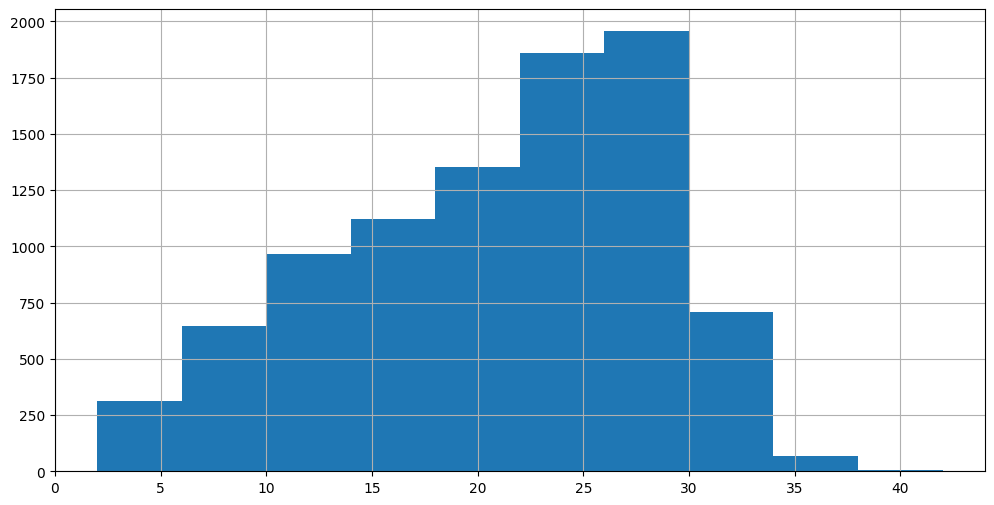

In [8]:
df['tweet_length'] = df['tokens_raw'].apply(lambda x: len(x))
plt.figure(figsize=(12,6))
df['tweet_length'].hist() #bins=100, range=(0,45), width=0.9) #, df['tweet_length'].mean(), df['tweet_length'].median()
plt.show()

In [9]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

Next, let's remove common stop words (e.g. "_the_", "_in_", etc.). In this next cell we will also remove some characters/punctuation, as well as hashtag tokens.

Note: If the following cell causes an error, then uncomment the code cell above and run it to download and load the nltk stopwords.

In [10]:
import re
from nltk.corpus import stopwords
stops = set(stopwords.words('english'))
chars2remove = set(['.','!','/', '?'])
df['tokens_raw'] = df['tokens_raw'].apply(lambda x: [w for w in x if w not in stops])
df['tokens_raw'] = df['tokens_raw'].apply(lambda x: [w for w in x if w not in chars2remove])
df['tokens_raw'] = df['tokens_raw'].apply(lambda x: [w for w in x if not re.match('^#', w)]) # remove hashtags
#df['tokens_raw'] = df['tokens_raw'].apply(lambda x: [w for w in x if not re.match('^http', w)]) # remove web links
#df['tokens_raw'] = df['tokens_raw'].apply(lambda x: [w for w in x if not re.match('^@', w)]) # remove web links

df.head()

,sentiment,text,tokens_raw,tweet_length
7010,positive,@AmericanAir I ended up on a flight to LA my fourth time on standby. Thanks! http://t.co/NA5G5EAKPA,"[@americanair, ended, flight, la, fourth, time, standby, thanks, http://t.co/na5g5eakpa]",18
9477,neutral,@JetBlue thanks! I only loose 'em at airports...1st time we found it. I think @fitbit needs to make flexes that stay on when carrying bags!,"[@jetblue, thanks, loose, ', em, airports, ..., 1st, time, found, think, @fitbit, needs, make, flexes, stay, carrying, bags]",31
4584,neutral,@SouthwestAir can take u to Midway-Chicago March 8th-April 6th. Can't make it then? @AmericanAir can get u to @fly2ohare year round. #FlyPBI,"[@southwestair, take, u, midway-chicago, march, 8th, -, april, 6th, can't, make, @americanair, get, u, @fly2ohare, year, round]",27
3460,negative,@AmericanAir is this how you let your employees treat your loyal customers? #attackingbabymomma #crazinessintherockies,"[@americanair, let, employees, treat, loyal, customers]",15
9065,negative,@USAirways so I still need to stay on hold? http://t.co/04SDytT7zd,"[@usairways, still, need, stay, hold, http://t.co/04sdytt7zd]",11


For the final step of text pre-processing we will lemmatize the tokens. Note that there are much better ways to do this but that we want to use a simple lemmatizer. For example, some lemmatizers also utilize a model internally to predict the part-of-speech for each word, since whether the word is a noun, adjective, verb, etc. will affect how lemmatization is done. Since we want to keep things simple here, and focus only on the lemmatization step, we'll assume every word is the same part of speech. Note that this is not by any means ideal (try to identify the incorrectly lemmatized token in the five tweets printed out below). In practice we would certainly utilize a 'smarter' lemmatizer.

The last step below is to combined the tokens back into a single string, which is stored in the column `textclean`.

In [11]:
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')
# nltk.download('omw-1.4')
lemmatizer = WordNetLemmatizer()
df['tokens'] = df['tokens_raw'].apply(lambda x: [lemmatizer.lemmatize(w, pos="v") for w in x])
#df['tokens'] = df['tokens_raw'].apply(lambda x: [lemmatizer.lemmatize(w) for w in x])

df['textclean'] = df['tokens'].apply(lambda x: ' '.join(x))
df.head()

[nltk_data] Downloading package wordnet to /root/nltk_data...


,sentiment,text,tokens_raw,tweet_length,tokens,textclean
7010,positive,@AmericanAir I ended up on a flight to LA my fourth time on standby. Thanks! http://t.co/NA5G5EAKPA,"[@americanair, ended, flight, la, fourth, time, standby, thanks, http://t.co/na5g5eakpa]",18,"[@americanair, end, flight, la, fourth, time, standby, thank, http://t.co/na5g5eakpa]",@americanair end flight la fourth time standby thank http://t.co/na5g5eakpa
9477,neutral,@JetBlue thanks! I only loose 'em at airports...1st time we found it. I think @fitbit needs to make flexes that stay on when carrying bags!,"[@jetblue, thanks, loose, ', em, airports, ..., 1st, time, found, think, @fitbit, needs, make, flexes, stay, carrying, bags]",31,"[@jetblue, thank, loose, ', em, airports, ..., 1st, time, find, think, @fitbit, need, make, flex, stay, carry, bag]",@jetblue thank loose ' em airports ... 1st time find think @fitbit need make flex stay carry bag
4584,neutral,@SouthwestAir can take u to Midway-Chicago March 8th-April 6th. Can't make it then? @AmericanAir can get u to @fly2ohare year round. #FlyPBI,"[@southwestair, take, u, midway-chicago, march, 8th, -, april, 6th, can't, make, @americanair, get, u, @fly2ohare, year, round]",27,"[@southwestair, take, u, midway-chicago, march, 8th, -, april, 6th, can't, make, @americanair, get, u, @fly2ohare, year, round]",@southwestair take u midway-chicago march 8th - april 6th can't make @americanair get u @fly2ohare year round
3460,negative,@AmericanAir is this how you let your employees treat your loyal customers? #attackingbabymomma #crazinessintherockies,"[@americanair, let, employees, treat, loyal, customers]",15,"[@americanair, let, employees, treat, loyal, customers]",@americanair let employees treat loyal customers
9065,negative,@USAirways so I still need to stay on hold? http://t.co/04SDytT7zd,"[@usairways, still, need, stay, hold, http://t.co/04sdytt7zd]",11,"[@usairways, still, need, stay, hold, http://t.co/04sdytt7zd]",@usairways still need stay hold http://t.co/04sdytt7zd


Now we will perform one-hot encoding using sklearn's, `CountVectorizer`, with the option `binary=True`. We'll go ahead and call the resulting vectorized data, `X`, or `X_train` since it is only the training dataset. As with conventional statistical models, "_X_" represents the set of predictors, or independent variables.

In [12]:
from sklearn.feature_extraction.text import CountVectorizer

#count_vectorizer = CountVectorizer(binary=True)
count_vectorizer = CountVectorizer(binary=True, min_df=2)
X_np = count_vectorizer.fit_transform(df['textclean']).toarray()

print(f"X_np.shape = {X_np.shape}")
type(X_np)

X_np.shape = (9000, 3842)


numpy.ndarray

Here is the full vocabulary created by the the `CountVectorizer`.

In [13]:
vocab = count_vectorizer.vocabulary_
vocab = {k: v for k, v in sorted(vocab.items(), key=lambda item: item[1], reverse=False)}
print(vocab)

{'00': 0, '000': 1, '01': 2, '02': 3, '03': 4, '05': 5, '05am': 6, '08': 7, '0hp': 8, '10': 9, '100': 10, '1000': 11, '101': 12, '1027': 13, '103': 14, '104': 15, '1081': 16, '10am': 17, '10hrs': 18, '10mins': 19, '10pm': 20, '10th': 21, '11': 22, '1109': 23, '1137': 24, '1142': 25, '117': 26, '1170': 27, '118': 28, '11am': 29, '11pm': 30, '11th': 31, '12': 32, '120': 33, '1200': 34, '1220': 35, '123': 36, '1230': 37, '1254': 38, '12pm': 39, '13': 40, '130': 41, '136': 42, '1389': 43, '13th': 44, '14': 45, '140': 46, '145': 47, '1472': 48, '15': 49, '150': 50, '152': 51, '1533': 52, '1534': 53, '1562': 54, '1571aus': 55, '15minutes': 56, '15th': 57, '16': 58, '1600': 59, '1613': 60, '1625': 61, '165': 62, '1657': 63, '17': 64, '1700': 65, '1701': 66, '174': 67, '18': 68, '180': 69, '1800': 70, '1826': 71, '1861': 72, '1898': 73, '19': 74, '1917': 75, '1970': 76, '1997': 77, '1am': 78, '1hr': 79, '1k': 80, '1m': 81, '1pm': 82, '1st': 83, '1ywxrfn0gr': 84, '20': 85, '200': 86, '2000': 87

---

### Q1: Choose two words to compare (different from "_wonderful_" vs "_incredible_").

Below you will choose your two words, which have similar meaning and which you suspect the model will treat similarly. Then, re-train the model and plot the histogram of the differences between learned weight values for each of your chosen words across the 128 hidden units in the first layer. Did the histograms show that the learned weight values were similar for your words? More similar than for the neighboring words compared to each other?

`Late vs delayed (my chosen words) performed marginally better than the presumably random words on either side. However, last vs late performed arguably better, although that makes some intuitive sense. latime vs deleted had a greater spread and a larger mean, so they performed worse.`

---

In [18]:
word1 = 'late'   # input your own word here
word2 = 'delayed'  # and a synonym for your word here

word1_idx = vocab[word1]
print(f"The index for '{word1}': {word1_idx}")

word2_idx = vocab[word2]
print(f"The index for '{word2}': {word2_idx}")


The index for 'late': 2101
The index for 'delayed': 1154


Next, let's look at the tweets themselves that contained the word _"great"_.

In [16]:
rows_w_word1 = np.where(X_np[:, word1_idx] == 1)[0]
print(rows_w_word1)
df.iloc[rows_w_word1,]

[  70  168  220  340  350  410  458  461  497  522  588  612  689  692
  723  743  865  883  903  935  985  990 1082 1119 1208 1232 1315 1355
 1392 1413 1473 1490 1495 1524 1534 1574 1580 1604 1623 1673 1678 1727
 1757 1769 1777 1786 1806 1833 1861 1899 2018 2040 2044 2082 2088 2113
 2206 2218 2338 2354 2519 2521 2551 2619 2620 2735 2858 3012 3271 3340
 3348 3390 3462 3490 3577 3656 3670 3715 3750 3764 3871 3907 3943 3999
 4031 4047 4055 4098 4335 4376 4423 4499 4504 4595 4606 4609 4637 4668
 4741 4773 4809 4838 4861 4870 4963 5039 5137 5165 5558 5565 5605 5644
 5665 5738 5748 5754 5766 5887 5924 5949 6032 6038 6154 6235 6294 6540
 6607 6638 6751 6765 6998 7032 7125 7169 7176 7201 7330 7406 7432 7451
 7481 7499 7551 7594 7630 7670 7707 7823 7833 7879 7883 7928 7971 8020
 8031 8091 8102 8133 8160 8195 8218 8289 8290 8302 8318 8369 8387 8392
 8409 8439 8503 8523 8549 8742 8745 8771 8772 8817 8884 8911 8959]


,sentiment,text,tokens_raw,tweet_length,tokens,textclean
9906,neutral,@SouthwestAir I enjoyed a call from my good friend he's Flight Booking Problems his flights elsewhere as I tweet one at a time I will tell as many as I can,"[@southwestair, enjoyed, call, good, friend, flight, booking, problems, flights, elsewhere, tweet, one, time, tell, many]",31,"[@southwestair, enjoy, call, good, friend, flight, book, problems, flight, elsewhere, tweet, one, time, tell, many]",@southwestair enjoy call good friend flight book problems flight elsewhere tweet one time tell many
4747,negative,"@united, there is no good word for describing how angry and pissed off of a customer you have made me.","[@united, ,, good, word, describing, angry, pissed, customer, made]",22,"[@united, ,, good, word, describe, angry, piss, customer, make]","@united , good word describe angry piss customer make"
4361,positive,"@AmericanAir ""Airport snow removal method #22...""\nKeep up the good work folks, this is where Cessna's become 747's! http://t.co/oUmC1LrXDN","[@americanair, "", airport, snow, removal, method, ..., "", keep, good, work, folks, ,, cessna's, become, 747, ', http://t.co/oumc1lrxdn]",26,"[@americanair, "", airport, snow, removal, method, ..., "", keep, good, work, folks, ,, cessna's, become, 747, ', http://t.co/oumc1lrxdn]","@americanair "" airport snow removal method ... "" keep good work folks , cessna's become 747 ' http://t.co/oumc1lrxdn"
8179,neutral,"@JetBlue Thx for the pointer, but Im good with the big monitor. Any advice on who I should pick to come our of the Western Conf (NBA)?","[@jetblue, thx, pointer, ,, im, good, big, monitor, advice, pick, come, western, conf, (, nba, )]",32,"[@jetblue, thx, pointer, ,, im, good, big, monitor, advice, pick, come, western, conf, (, nba, )]","@jetblue thx pointer , im good big monitor advice pick come western conf ( nba )"
2771,negative,@united i have talked to them...on standby for tomorrow but it doesn't look good. May have to stay here till Friday &amp; that's not guaranteed,"[@united, talked, ..., standby, tomorrow, look, good, may, stay, till, friday, &, that's, guaranteed]",28,"[@united, talk, ..., standby, tomorrow, look, good, may, stay, till, friday, &, that's, guarantee]",@united talk ... standby tomorrow look good may stay till friday & that's guarantee
...,...,...,...,...,...,...
712,negative,@AmericanAir a school trip of 38 including myself had to sleep over in the airport and are all on different standby flights.This is not good,"[@americanair, school, trip, 38, including, sleep, airport, different, standby, flights.this, good]",25,"[@americanair, school, trip, 38, include, sleep, airport, different, standby, flights.this, good]",@americanair school trip 38 include sleep airport different standby flights.this good
6734,negative,@JetBlue @dgruber1700 oh wow and I'm complaining about two hour on the run way shucks JetBlue NOT GOOD your service was better than this,"[@jetblue, @dgruber1700, oh, wow, complaining, two, hour, run, way, shucks, jetblue, good, service, better]",24,"[@jetblue, @dgruber1700, oh, wow, complain, two, hour, run, way, shuck, jetblue, good, service, better]",@jetblue @dgruber1700 oh wow complain two hour run way shuck jetblue good service better
445,negative,"@united In ORD, waited 20 min after crew members left before gate items came. Flight attendant sarcastically said good luck and walked away.","[@united, ord, ,, waited, 20, min, crew, members, left, gate, items, came, flight, attendant, sarcastically, said, good, luck, walked, away]",26,"[@united, ord, ,, wait, 20, min, crew, members, leave, gate, items, come, flight, attendant, sarcastically, say, good, luck, walk, away]","@united ord , wait 20 min crew members leave gate items come flight attendant sarcastically say good luck walk away"
3029,positive,@JetBlue Success! Good work JetBlue team,"[@jetblue, success, good, work, jetblue, team]",7,"[@jetblue, success, good, work, jetblue, team]",@jetblue success good

In [19]:
rows_w_word2 = np.where(X_np[:, word2_idx] == 1)[0]
print(rows_w_word2)
df.iloc[rows_w_word2,]

[3335 7452 8330]


,sentiment,text,tokens_raw,tweet_length,tokens,textclean
1194,negative,@USAirways well its 11:45am and just got an email that my 11am flight is delayed-thats not right,"[@usairways, well, 11:45, got, email, 11am, flight, delayed-thats, right]",18,"[@usairways, well, 11:45, get, email, 11am, flight, delayed-thats, right]",@usairways well 11:45 get email 11am flight delayed-thats right
9761,negative,@USAirways are there such things as non-delayed flights or na? Get your shit together and get me out of here,"[@usairways, things, non-delayed, flights, na, get, shit, together, get]",21,"[@usairways, things, non-delayed, flight, na, get, shit, together, get]",@usairways things non-delayed flight na get shit together get
7082,negative,@United flight delayed-no one remembered to turn the heat on flight 559 leaving ORD-seriously???,"[@united, flight, delayed-no, one, remembered, turn, heat, flight, 559, leaving, ord-seriously]",17,"[@united, flight, delayed-no, one, remember, turn, heat, flight, 559, leave, ord-seriously]",@united flight delayed-no one remember turn heat flight 559 leave ord-seriously


Confirm that the input, `X`, has n rows and a column for each word (token) in the vocabulary.

In [20]:
X = torch.tensor(X_np).float()
X.size()

torch.Size([9000, 3842])

In [21]:
# look at one observation and see how may tokens there are (i.e. how many 1's are in the row, and how many 0's)
pd.DataFrame(X_np[1,:]).value_counts()

,count
0,
0,3827
1,15


In [22]:
labels = df['sentiment'].unique()
enum_labels = enumerate(labels)
label_to_idx = dict((lab, i) for i,lab in enum_labels)
print(f"label dictionary: {label_to_idx}")
y = torch.tensor([label_to_idx[lab] for lab in df['sentiment']])

label dictionary: {'positive': 0, 'neutral': 1, 'negative': 2}


In [23]:
class AirlineTweetDataset(Dataset):
    def __init__(self, observations, labels):
        self.obs = observations
        self.labs = labels
        self.create_split(len(observations))

    def create_split(self, n, seed=2, train_perc=0.7):
        random.seed(seed)
        indices = list(range(n))
        random.shuffle(indices)
        self._train_ids = list(indices[:int(n * train_perc)])
        self._test_ids = list(indices[int(n * train_perc):])
        self._split_X = self.obs[self._train_ids]
        self._split_y = self.labs[self._train_ids]

    def set_split(self, split='train'):
        if split == 'train':
            self._split_X = self.obs[self._train_ids]
            self._split_y = self.labs[self._train_ids]
        else:
            self._split_X = self.obs[self._test_ids]
            self._split_y = self.labs[self._test_ids]

    def __len__(self):
        return len(self._split_y)

    def __getitem__(self, idx):
        return {'x':self._split_X[idx], 'y':self._split_y[idx]}

    def get_num_batches(self, batch_size):
        return len(self) // batch_size

dataset = AirlineTweetDataset(X, y)
dataset.create_split(len(X), seed=42, train_perc=0.85)

In [24]:
dataset.set_split('train')
print(f"len(dataset) = {len(dataset)}")
#len(dataset[:]['x'])
dataset[0]['x']

len(dataset) = 7650


tensor([0., 0., 0.,  ..., 0., 0., 0.])

Confirm that there are no NaN, and that all numerical values are finite.

In [25]:
dataset[:]['x'].numpy()[0,:5]

array([0., 0., 0., 0., 0.], dtype=float32)

In [26]:
assert not np.any(np.isnan(dataset[:]['x'].numpy()))
assert np.all(np.isfinite(dataset[:]['x'].numpy()))

In [27]:
class AirlineTweetClassifier(nn.Module):
    """ A 2-layer Multilayer Perceptron for classifying surnames """
    def __init__(self, input_dim, hidden_dim, output_dim):
        """
        Args:
            input_dim (int): the size of the input embeddings
            hidden_dim (int): the output size of the first Linear layer
            output_dim (int): the output size of the second Linear layer
        """
        super(AirlineTweetClassifier, self).__init__()

        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 32)
        self.fc3 = nn.Linear(32, output_dim)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x_in, apply_softmax=False):
        """The forward pass of the classifier

        Args:
            x_in (torch.Tensor): an input data tensor.
                x_in.shape should be (batch, input_dim)
            apply_softmax (bool): a flag for the softmax activation
                should be false if used with the Cross Entropy losses
        Returns:
            the resulting tensor. tensor.shape should be (batch, output_dim)
        """
        intermediate_vector = F.relu(self.fc1(x_in))

        intermediate_vector = F.relu(self.fc2(intermediate_vector))
        intermediate_vector = self.dropout(intermediate_vector)

        prediction_vector = self.fc3(intermediate_vector)

        if apply_softmax:
            prediction_vector = F.softmax(prediction_vector, dim=1)

        return prediction_vector

#### Hyperparameters for model with one-hot encoded inputs

In [28]:
batch_size = 32
learning_rate = 0.001
num_epochs = 20
device = 'cpu'

dataloader = DataLoader(dataset=dataset, batch_size=batch_size, shuffle=True)

Take one quick look at the size of the training and validation splits.

In [29]:
dataset.set_split('train')
print(len(dataloader) * batch_size)
dataset.set_split('val')
print(len(dataloader) * batch_size)

7680
1376


In [30]:
seed = 2
np.random.seed(seed)
torch.manual_seed(seed)
random.seed(seed)

# create the dataset, model and define loss function and optimizer
model = AirlineTweetClassifier(len(dataset[0]['x']), 128, 3)
loss_fun = nn.CrossEntropyLoss()#weights)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [31]:
epoch_bar = tqdm.notebook.tqdm(desc='training routine', total=num_epochs, position=0)

dataset.set_split('train')
train_bar = tqdm.notebook.tqdm(desc='split=train', total=dataset.get_num_batches(batch_size), position=1, leave=True)

dataset.set_split('val')
val_bar = tqdm.notebook.tqdm(desc='split=val', total=dataset.get_num_batches(batch_size), position=1, leave=True)

losses = {'train':[], 'val':[]}

for epoch in range(num_epochs):

    dataset.set_split('train')
    model.train()
    running_loss_train = 0.0

    for batch_i, batch_data in enumerate(dataloader):
        tweets = batch_data['x'].to(device)
        labels = batch_data['y'].to(device)

        # forward
        outputs = model(tweets)
        loss = loss_fun(outputs, labels)
        losses['train'].append(loss.item())
        running_loss_train += loss.item()

        # backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        #if (batch_i+1) % 10 == 0:
        #    print(f"    train batch {batch_i+1:3.0f} (of {len(dataloader):3.0f}) loss: {loss.item():.4f}")
            # update bar
        train_bar.set_postfix(loss=running_loss_train, epoch=epoch)
        train_bar.update()

    train_bar.set_postfix(loss=running_loss_train/dataset.get_num_batches(batch_size), epoch=epoch)
    train_bar.update()


    running_loss_train = running_loss_train / len(dataset)

    dataset.set_split('val')
    model.eval() # turn off the automatic differentiation
    running_loss_val = 0.0

    for batch_i, batch_data in enumerate(dataloader):
        tweets = batch_data['x'].to(device)
        labels = batch_data['y'].to(device)


        # forward (no backward step for validation data)
        outputs = model(tweets)
        loss = loss_fun(outputs, labels)
        losses['val'].append(loss.item())
        running_loss_val += loss.item()
        #if (batch_i+1) % 20 == 0:
        #    print(f"    valid batch {i+1:3.0f} (of {len(dataloader):3.0f}) loss: {loss.item():.4f}")
        val_bar.set_postfix(loss=running_loss_val, epoch=epoch)
        val_bar.update()

    val_bar.set_postfix(loss=running_loss_val/dataset.get_num_batches(batch_size), epoch=epoch)
    val_bar.update()

    train_bar.n = 0
    val_bar.n = 0
    epoch_bar.update()

    running_loss_val = running_loss_val / len(dataset)


training routine:   0%|          | 0/20 [00:00<?, ?it/s]

split=train:   0%|          | 0/239 [00:00<?, ?it/s]

split=val:   0%|          | 0/42 [00:00<?, ?it/s]

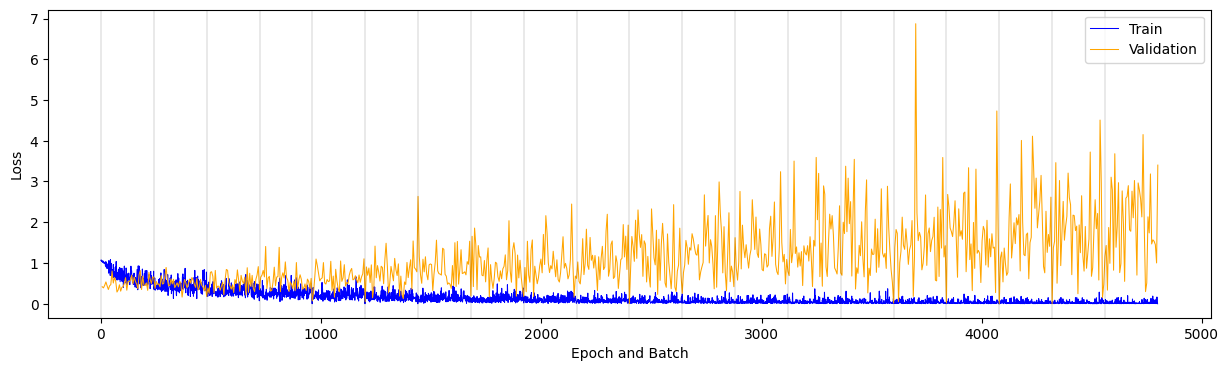

In [32]:
matplotlib.rc('figure', figsize=(15,4))
val_ticks = [(i+1)*len(losses['train'])/len(losses['val']) for i in range(len(losses['val']))]
plt.plot(range(len(losses['train'])), losses['train'], c='blue', lw=0.75)
plt.plot(val_ticks, losses['val'], c='orange', lw=0.75)
for i in range(num_epochs):
    plt.axvline(x=i*len(losses['train'])/num_epochs, c='black', lw=0.25, alpha=0.5)
plt.ylabel('Loss')
plt.xlabel('Epoch and Batch')
plt.legend(('Train','Validation'))

In [33]:
# Test the model on full validation set
dataset.set_split('val')

y_true = []
y_pred = []
with torch.no_grad():
    correct = 0
    total = 0
    for batch_data in dataloader:
        tweets = batch_data['x'].to(device)
        labels = batch_data['y'].to(device)
        outputs = model(tweets)
        _, predicted = torch.max(outputs.data, 1)
        y_true += labels.tolist()
        y_pred += predicted.tolist()
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    print(f"Accuracy (on {len(dataloader)*batch_size} validation tweets): {100 * correct / total:.2f}%")


Accuracy (on 1376 validation tweets): 80.22%


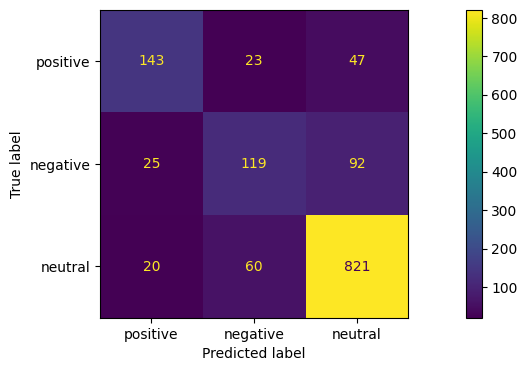

In [34]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['positive','negative','neutral'])
disp.plot()

In [35]:
torchinfo.summary(model, tuple(dataset[0]['x'].size()))

Layer (type:depth-idx)                   Output Shape              Param #
AirlineTweetClassifier                   [3]                       --
├─Linear: 1-1                            [128]                     491,904
├─Linear: 1-2                            [32]                      4,128
├─Dropout: 1-3                           [32]                      --
├─Linear: 1-4                            [3]                       99
Total params: 496,131
Trainable params: 496,131
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 63.10
Input size (MB): 0.02
Forward/backward pass size (MB): 0.00
Params size (MB): 1.98
Estimated Total Size (MB): 2.00

Let's now retrieve the weight parameters that are associated with the words (i.e. tokens) that have similar meaning, "wonderful", "incredible", "terrific". These words were in the vocabulary at following locations.
* index for 'wonderful': 3782
* index for 'incredible': 1930
* index for 'terrific': 3425

In [36]:
fc1_weights = model.fc1.weight.data
print(f"first model layer has weight matrix with shape = {fc1_weights.shape}")

first model layer has weight matrix with shape = torch.Size([128, 3842])


In [37]:
#wonderful_idx = vocab['wonderful']
#incredible_idx = vocab['incredible']
unit_i = 0
print(f"word1 index: {word1_idx}")
print(f"  fc1_weights[{unit_i},{[word1_idx-1,word1_idx, word1_idx+1]}]: {fc1_weights[unit_i,word1_idx-1:word1_idx+2]}")
print(f"word2 index: {word2_idx}")
print(f"  fc1_weights[{unit_i},{[word2_idx-1,word2_idx, word2_idx+1]}]: {fc1_weights[unit_i,word2_idx-1:word2_idx+2]}")

word1 index: 2101
  fc1_weights[0,[2100, 2101, 2102]]: tensor([-0.0147,  0.0540, -0.0465], device='cuda:0')
word2 index: 1154
  fc1_weights[0,[1153, 1154, 1155]]: tensor([-0.0792,  0.0367,  0.1195], device='cuda:0')


In [39]:
fc1_weights_cpu = fc1_weights.cpu()
diffs = {"cont1":[], "word1_vs_word2":[], "cont2":[]}
for i in range(128):
    diffs["cont1"].append(abs(fc1_weights_cpu[i,word1_idx-1] - fc1_weights_cpu[i,word2_idx-1]))
    diffs["word1_vs_word2"].append(abs(fc1_weights_cpu[i,word1_idx] - fc1_weights_cpu[i,word2_idx]))
    diffs["cont2"].append(abs(fc1_weights_cpu[i,word1_idx+1] - fc1_weights_cpu[i,word2_idx+1]))

# convert each list to a numpy array
for key in diffs:
    diffs[key] = np.array(diffs[key])

In [40]:
# generate summary statistics for the differences for weight values
diffs_df = pd.DataFrame(diffs)
diffs_df.describe()

,cont1,word1_vs_word2,cont2
count,128.000000,128.000000,128.000000
mean,0.058208,0.047484,0.096678
std,0.053726,0.032159,0.054265
min,0.001921,0.000446,0.002928
25%,0.020552,0.021735,0.052826
50%,0.043377,0.042284,0.100127
75%,0.074284,0.068196,0.128397
max,0.331435,0.152765,0.227704


In [41]:
vocab = count_vectorizer.vocabulary_

# find which key vocab is associated with the index 4139
for key, value in vocab.items():
    if value == word1_idx-1:
        w_at_incredible_idx_minus_1 = key
        print(f"word at index {word1_idx-1}: {key}")
    if value == word2_idx-1:
        w_at_wonderful_idx_minus_1 = key
        print(f"word at index {word2_idx-1}: {key}")
    if value == word1_idx+1:
        w_at_incredible_idx_plus_1 = key
        print(f"word at index {word1_idx+1}: {key}")
    if value == word2_idx+1:
        w_at_wonderful_idx_plus_1 = key
        print(f"word at index {word2_idx+1}: {key}")



word at index 2100: last
word at index 1153: delay
word at index 1155: delete
word at index 2102: latimes


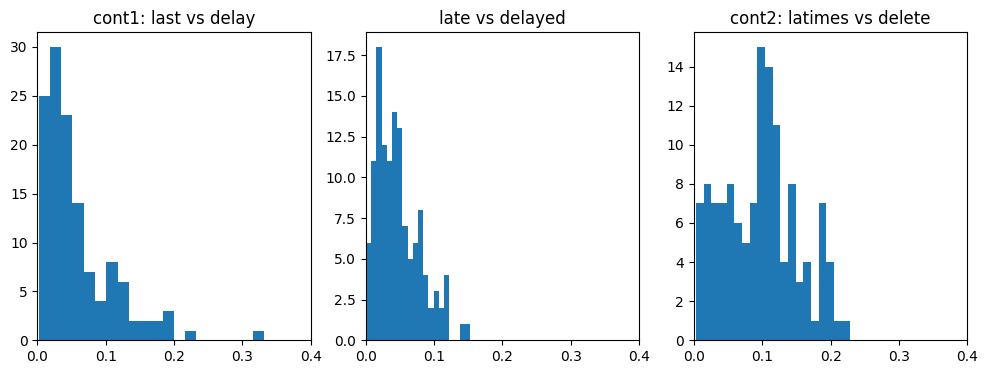

In [42]:
# plots of the differences as three different histograms
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.hist(diffs["cont1"], bins=20)
# set x-axis limits to be the same for all three plots
plt.xlim(0,0.4)
plt.title(f"cont1: {w_at_incredible_idx_minus_1} vs {w_at_wonderful_idx_minus_1}")
plt.subplot(1,3,2)
plt.hist(diffs["word1_vs_word2"], bins=20)
plt.xlim(0,0.4)
plt.title(f"{word1} vs {word2}")
plt.subplot(1,3,3)
plt.hist(diffs["cont2"], bins=20)
plt.xlim(0,0.4)
plt.title(f"cont2: {w_at_incredible_idx_plus_1} vs {w_at_wonderful_idx_plus_1}")
plt.show()


In [43]:
# length of an input is
len(dataset[0]['x'])

3842

In [44]:
import gensim.downloader as api

# Download and load the 'glove-wiki-gigaword-100' model (100 dimensions)
vec = api.load("glove-wiki-gigaword-100")

[==================================================] 100.0% 128.1/128.1MB downloaded


---

### Q1: Choose two words to compare (different from "_wonderful_" vs "_incredible_").

Q2: Add your two words the list of words whose embeddings are displayed and compared. Do your two chosen words have similar embeddings? In other words, is the distance between your embeddings very small?

`<input your answer here>`

---

In [ ]:
examples = ['annoy', 'annoyed', 'disappointed', 'sad', 'happy', 'pilot', 'attendant', 'crew', 'suitcase', 'luggage', 'carryon', 'wonderful', 'incredible', 'terrific','great']
embeddings = vec[examples]
embeddings[0,:] # just the first embedding (you can verify by confirming that it is 100 elements long)

In [ ]:
def compare_words_with_colors(vecs, wds):
    wdsr = wds[:]
    wdsr.reverse()

    dim = len(vecs[0])

    fig = plt.figure(num=None, figsize=(16, 4), dpi=80, facecolor='w', edgecolor='k')
    ax = fig.add_subplot(111)
    ax.set_facecolor('gray')

    for i,v in enumerate(vecs):
        ax.scatter(range(dim), [i]*dim, c=vecs[i], cmap='Spectral', s=150, marker='s')

    #plt.xticks(range(100), [i+1 for i in range(100)])
    plt.xlabel('Dimension')
    plt.yticks(range(len(wds)), wds)

    plt.show()

compare_words_with_colors(embeddings, examples)
#examples.reverse()

In [ ]:
emb1 = embeddings[0]

In [ ]:
# CosineSimilarity over the embedding dimension
cos = torch.nn.CosineSimilarity(dim=2)

# Compare every embedding to every other embedding
# Shapes become:
#   a: (16, 1, 100)
#   b: (1, 16, 100)
# Broadcasting gives pairwise comparisons of shape (16, 16, 100)
a = torch.tensor(embeddings).unsqueeze(1)
b = torch.tensor(embeddings).unsqueeze(0)

# Result is a 16 x 16 matrix of scalar cosine similarities
sim_matrix = cos(a, b)   # shape: (16, 16)

# Convert to pandas DataFrame
similarities = pd.DataFrame(
    sim_matrix.numpy(),
    index=[f"emb_{i}" for i in range(embeddings.shape[0])],
    columns=[f"emb_{i}" for i in range(embeddings.shape[0])]
)

print(similarities.shape)

In [ ]:
similarities

In [ ]:
# rename the rows and columns of similarities using 'examples'
similarities.columns = examples
similarities.index = examples
similarities

np.fill_diagonal(similarities.values, None)


In the cell above we created a similarity matrix, let's now see what it looks like. Note that since we are plotting pairwise similarities, larger values will be green and will suggest that the word the corresponding row is close to the word in the corresponding columns (and vice versa).

Similarly, words that are not similar to each other will have a low similarity, and will be plotted in red.

In [ ]:
plt.figure(figsize=(8,6))
sns.color_palette("viridis", as_cmap=True)
#sns.color_palette("mako", as_cmap=True)
sns.heatmap(
    similarities,
    cmap='RdYlGn',  # Reverse the 'RdYlGn' colormap to have green for larger values and red for smaller values
    linewidth=1
)


In [ ]:
data_URL = 'https://raw.githubusercontent.com/sgeinitz/DSML4220/main/data/airlinetweets.csv'
df = pd.read_csv(data_URL)
print(f"df.shape: {df.shape}")
pd.set_option("display.max_colwidth", 240)
df.head(10)

In [ ]:
df.head()

In [ ]:
random.seed(2)
indices = list(range(len(df)))
random.shuffle(indices)

df_test = df.iloc[indices[9000:],]
df = df.iloc[indices[:9000],]

In [ ]:
df.sentiment.value_counts(normalize=False)

In [ ]:
# use gensim to tokenize the text, so that we can then retrieve the embedding for each token
from gensim.utils import tokenize
df['tokens_raw'] = df['text'].apply(lambda x: list(tokenize(x.lower())))
df.head()

In [ ]:
df['tweet_length'] = df['tokens_raw'].apply(lambda x: len(x))
#plt.figure(figsize=(12,6))
#df['tweet_length'].hist() #bins=100, range=(0,45), width=0.9) #, df['tweet_length'].mean(), df['tweet_length'].median()
#plt.show()

In [ ]:
df.iloc[rows_w_word1,].index.sort_values()

In [ ]:
tweet_i= 53
tokens_for_tweet = df['tokens_raw'][tweet_i]

# Filter tokens that are present in the GloVe vocabulary
known_tokens = [token for token in tokens_for_tweet if token in vec.key_to_index]

# If the token is known, then get the embedding
if known_tokens:
    tweet_embeddings = vec[known_tokens]
# If there is no embedding for this token, then create an empty tensor of the correct size
else:
    tweet_embeddings = torch.empty(0, vec.vector_size)

print(f"sentiment of this tweet: {df['sentiment'][tweet_i]}")
print(f"tweet_embeddings.shape = {tweet_embeddings.shape}")
for i in range(len(tweet_embeddings)):
    print(f"    token, '{df['tokens_raw'][tweet_i][i]}' (at pos {i:2.0f}) has tweet_embeddings[:5] = {tweet_embeddings[i][:5]}")

In [ ]:
df.iloc[rows_w_word2,].index.sort_values()

In [ ]:
tweet_i= 18
tokens_for_tweet = df['tokens_raw'][tweet_i]
known_tokens = [token for token in tokens_for_tweet if token in vec.key_to_index]
if known_tokens:
    tweet_embeddings = vec[known_tokens]
else:
    tweet_embeddings = torch.empty(0, vec.vector_size)
print(f"sentiment of this tweet: {df['sentiment'][tweet_i]}")
print(f"tweet_embeddings.shape = {tweet_embeddings.shape}")
for i in range(len(tweet_embeddings)):
    print(f"    token, '{df['tokens_raw'][tweet_i][i]}' (at pos {i:2.0f}) has tweet_embeddings[:5] = {tweet_embeddings[i][:5]}")

The tweet above had 23 tokens in it, which we can quickly confirm here by looking at the shape of it:

In [ ]:
tweet_embeddings.shape

Before we continue we must decide what a good length will be for a max-length of the number of tokens to keep. Let's look at a histogram of the lenghts of each tweet (where length equals the number of raw tokens).

In [ ]:
def meanTweetEmbeddings(raw_tokens):
    #embeddings = vec.get_vecs_by_tokens(raw_tokens, lower_case_backup=True)

    known_tokens = [token for token in raw_tokens if token in vec.key_to_index]
    if known_tokens:
      embeddings = torch.tensor(vec[known_tokens])
    else:
      embeddings = torch.empty(0, vec.vector_size)

    n_embs = 0
    emb_sum = torch.zeros((embeddings.shape[1]))
    for i in range(min(embeddings.shape[0], 35)): # max number of tokens in a tweet is 35
        if embeddings[i].abs().sum() > 0:
            n_embs += 1
            emb_sum += embeddings[i]
    if n_embs > 0:
        emb_avg = emb_sum / n_embs
    else:
        emb_avg = torch.zeros((embeddings.shape[1]))
    if np.any(np.isnan(emb_avg.numpy())):
        print(f"exists an nan: {emb_sum}")
    return emb_avg

X_int = df['tokens_raw'].apply(lambda x: meanTweetEmbeddings(x)).values
print(f"X_int.shape = {X_int.shape}")
X_int[:2]

In [ ]:
X_int[0].shape

In [ ]:
if len(X_int[0] > 50):
    avg_embedding = False
else:
    avg_embedding = True

X = torch.stack(tuple(X_int))
X.shape
#X[:2]

There should be 9000 rows in X, since this is the number of tweets (i.e. observations) in the training data.

The number of columns is the _embedding size_ itself.

In [ ]:
labels = df['sentiment'].unique()
enum_labels = enumerate(labels)
label_to_idx = dict((lab, i) for i,lab in enum_labels)
print(f"label dictionary: {label_to_idx}")
y = torch.tensor([label_to_idx[lab] for lab in df['sentiment']])

In [ ]:
# Can be a good idea to occassionally check that the dims (or shapes) agree for the inputs (X) and labels (y)
assert len(X) == len(y)

In [ ]:
class AirlineTweetDataset(Dataset):
    def __init__(self, observations, labels):
        self.obs = observations
        self.labs = labels
        self.create_split(len(observations))

    def create_split(self, n, seed=2, train_perc=0.7):
        random.seed(seed)
        indices = list(range(n))
        random.shuffle(indices)
        self._train_ids = list(indices[:int(n * train_perc)])
        self._test_ids = list(indices[int(n * train_perc):])
        self._split_X = self.obs[self._train_ids]
        self._split_y = self.labs[self._train_ids]

    def set_split(self, split='train'):
        if split == 'train':
            self._split_X = self.obs[self._train_ids]
            self._split_y = self.labs[self._train_ids]
        else:
            self._split_X = self.obs[self._test_ids]
            self._split_y = self.labs[self._test_ids]

    def __len__(self):
        return len(self._split_y)

    def __getitem__(self, idx):
        return {'x':self._split_X[idx], 'y':self._split_y[idx]}

    def get_num_batches(self, batch_size):
        return len(self) // batch_size

dataset = AirlineTweetDataset(X, y)
dataset.create_split(len(X), seed=42, train_perc=0.85)

In [ ]:
dataset.set_split('train')
print(f"len(dataset) = {len(dataset)}")
len(dataset[:]['x'])
dataset[0]['x']

In [ ]:
assert not np.any(np.isnan(dataset[:]['x'].numpy()))
assert np.all(np.isfinite(dataset[:]['x'].numpy()))

#### Hyperparameters for model with GloVe embeddings

We'll use the same training configuration as before, although it is worth noting that this model would likely benefit from more training.

In [ ]:
# use same batch_size, learning_rate, and epochs as before
batch_size = 32
learning_rate = 0.001
num_epochs = 20
device = 'cpu'

In [ ]:
seed = 2
np.random.seed(seed)
torch.manual_seed(seed)
random.seed(seed)

# create dataset, model and define loss function and optimizer
dataloader = DataLoader(dataset=dataset, batch_size=batch_size, shuffle=True)
model_w_embeddings = AirlineTweetClassifier(len(dataset[0]['x']), 256, 3)
loss_fun = nn.CrossEntropyLoss()#weights)
optimizer = torch.optim.Adam(model_w_embeddings.parameters(), lr=learning_rate)

In [ ]:
epoch_bar = tqdm.notebook.tqdm(desc='training routine', total=num_epochs, position=0)

dataset.set_split('train')
train_bar = tqdm.notebook.tqdm(desc='split=train', total=dataset.get_num_batches(batch_size), position=1, leave=True)

dataset.set_split('val')
val_bar = tqdm.notebook.tqdm(desc='split=val', total=dataset.get_num_batches(batch_size), position=1, leave=True)

losses = {'train':[], 'val':[]}

for epoch in range(num_epochs):

    dataset.set_split('train')
    model_w_embeddings.train()
    running_loss_train = 0.0

    for batch_i, batch_data in enumerate(dataloader):
        tweets = batch_data['x'].to(device)
        labels = batch_data['y'].to(device)

        # forward
        outputs = model_w_embeddings(tweets)
        loss = loss_fun(outputs, labels)
        losses['train'].append(loss.item())
        running_loss_train += loss.item()

        # backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        #if (batch_i+1) % 10 == 0:
        #    print(f"    train batch {batch_i+1:3.0f} (of {len(dataloader):3.0f}) loss: {loss.item():.4f}")
            # update bar
        train_bar.set_postfix(loss=running_loss_train, epoch=epoch)
        train_bar.update()

    train_bar.set_postfix(loss=running_loss_train/dataset.get_num_batches(batch_size), epoch=epoch)
    train_bar.update()


    running_loss_train = running_loss_train / len(dataset)

    dataset.set_split('val')
    model_w_embeddings.eval() # turn off the automatic differentiation
    running_loss_val = 0.0

    for batch_i, batch_data in enumerate(dataloader):
        tweets = batch_data['x'].to(device)
        labels = batch_data['y'].to(device)


        # forward (no backward step for validation data)
        outputs = model_w_embeddings(tweets)
        loss = loss_fun(outputs, labels)
        losses['val'].append(loss.item())
        running_loss_val += loss.item()
        #if (batch_i+1) % 20 == 0:
        #    print(f"    valid batch {i+1:3.0f} (of {len(dataloader):3.0f}) loss: {loss.item():.4f}")
        val_bar.set_postfix(loss=running_loss_val, epoch=epoch)
        val_bar.update()

    val_bar.set_postfix(loss=running_loss_val/dataset.get_num_batches(batch_size), epoch=epoch)
    val_bar.update()

    train_bar.n = 0
    val_bar.n = 0
    epoch_bar.update()

    running_loss_val = running_loss_val / len(dataset)


In [ ]:
matplotlib.rc('figure', figsize=(15,4))
val_ticks = [(i+1)*len(losses['train'])/len(losses['val']) for i in range(len(losses['val']))]
plt.plot(range(len(losses['train'])), losses['train'], c='blue', lw=0.75)
plt.plot(val_ticks, losses['val'], c='orange', lw=0.75)
for i in range(num_epochs):
    plt.axvline(x=i*len(losses['train'])/num_epochs, c='black', lw=0.25, alpha=0.5)
plt.ylabel('Loss')
plt.xlabel('Epoch and Batch')
plt.legend(('Train','Validation'))

In [ ]:
# Test the model
model_w_embeddings.eval()
dataset.set_split('val')
y_true = []
y_pred = []

with torch.no_grad():
    correct = 0
    total = 0
    for batch_data in dataloader:
        tweets = batch_data['x'].to(device)
        labels = batch_data['y'].to(device)
        outputs = model_w_embeddings(tweets)
        _, predicted = torch.max(outputs.data, 1)
        y_true += labels.tolist()
        y_pred += predicted.tolist()
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    print(f"Accuracy (on {len(dataloader)*batch_size} validation tweets): {100 * correct / total:.2f}%")


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['positive','negative','neutral'])
disp.plot()

In [ ]:
# length of an input is
len(dataset[0]['x'])

In [ ]:
import torchinfo
torchinfo.summary(model_w_embeddings, tuple(dataset[0]['x'].size()))

In [ ]:
100*256 + 256

---

### Q3: How much smaller is the model with embeddings than the model with one-hot encoded inputs?


`<input your answer here>`

---